# 09. 피크 타겟팅 개선 버전
### 변경사항
1. 피크 시간대 피처 추가 (is_peak_hour, peak_temp_interaction)
2. 폭염 + 피크 복합 가중치 적용
3. 피크 구간 별도 성능 평가
4. 전후 비교 시각화

## 📦 라이브러리 임포트
08번과 동일한 구성. 09번에서는 `LinearRegression`을 하이브리드 비교용으로만 가져옴.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import optuna
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from xgboost import XGBRegressor

font_path = r"C:\Users\User\Desktop\MyRepo\Portfolio\Portfolio_ver2\5_fonts\Pretendard-Medium.otf"
font_name = fm.FontProperties(fname=font_path).get_name()
fm.fontManager.addfont(font_path)
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False
print(f'폰트: {font_name}')

폰트: Pretendard


## 1. 데이터 로드 및 피처 엔지니어링

## 📂 데이터 로드
08번과 동일. `sort_values('datetime')` 시계열 정렬 필수.

In [2]:
df = pd.read_csv(r"C:\Users\User\Desktop\MyRepo\Portfolio\Portfolio_ver2\1_data\processed\df_final_v2.csv")
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)

df['강수량(mm)'] = df['강수량(mm)'].fillna(0)
df['일사(MJ/m2)'] = df['일사(MJ/m2)'].fillna(0)

print(f'데이터 기간: {df["datetime"].min()} ~ {df["datetime"].max()}')
print(f'전체 행 수: {len(df):,}')

데이터 기간: 2023-01-08 01:00:00 ~ 2025-01-01 00:00:00
전체 행 수: 17,376


## 🔧 피처 엔지니어링 - 피크 타겟팅 신규 피처 추가
**08번 피처를 그대로 계승하고 피크 관련 4개 피처 추가**

**신규 피처 상세 설명**

| 피처 | 계산 방법 | 의미 |
|------|---------|------|
| `is_peak_hour` | hour가 14~17시이면 1, 아니면 0 | 서울 전력 수요 피크 시간대 명시적 표시 |
| `peak_CDD_interaction` | CDD × is_peak_hour | 더울 때 피크시간이 겹치면 수요 폭발 → 두 변수의 상호작용 포착 |
| `peak_heatwave` | is_heatwave × is_peak_hour | 폭염 + 피크 동시 발생 = 가장 극단적인 수요 상황 |
| `ratio_to_daily_max` | 전날 같은 시간 소비량 / 전날 최대 소비량 | 하루 중 현재가 피크에 얼마나 가까운지 비율로 표현 |

**왜 피크 시간을 14~17시로 설정했나?**
- 서울 전력 데이터 기준, 여름철 냉방 수요가 오후 2~5시에 최고조
- 업무용 빌딩 + 가정 냉방이 동시에 최대로 가동되는 시간대
- 에너지 운영 경험에서 나온 도메인 지식 적용

In [3]:
TARGET = '전력사용량(MWh)'

# ── 기존 Rolling 피처 (08번과 동일) ─────────────────────────────────
df['rolling_3h_mean']  = df[TARGET].shift(1).rolling(3).mean()
df['rolling_6h_mean']  = df[TARGET].shift(1).rolling(6).mean()
df['rolling_6h_max']   = df[TARGET].shift(1).rolling(6).max()
df['rolling_24h_mean'] = df[TARGET].shift(1).rolling(24).mean()
df['rolling_24h_std']  = df[TARGET].shift(1).rolling(24).std()
df['temp_3h_mean']     = df['기온(°C)'].shift(1).rolling(3).mean()
df['temp_6h_max']      = df['기온(°C)'].shift(1).rolling(6).max()

# ── CDD/HDD ──────────────────────────────────────────────────────────
if 'CDD' not in df.columns:
    df['CDD'] = np.maximum(0, df['기온(°C)'] - 24)
if 'HDD' not in df.columns:
    df['HDD'] = np.maximum(0, 18 - df['기온(°C)'])

df['CDD_squared']  = df['CDD'] ** 2
df['is_heatwave']  = (df['기온(°C)'] >= 33).astype(int)
df['temp_humidity'] = df['기온(°C)'] * df['습도(%)']

# ── 신규: 피크 시간대 피처 ───────────────────────────────────────────
# 오후 2~5시 = 서울 전력 수요 피크 타임
df['is_peak_hour'] = df['hour'].between(14, 17).astype(int)

# 피크 시간 × CDD (더울 때 피크면 수요 폭발)
df['peak_CDD_interaction'] = df['CDD'] * df['is_peak_hour']

# 피크 시간 × 폭염 (가장 극단적인 조합)
df['peak_heatwave'] = df['is_heatwave'] * df['is_peak_hour']

# 일별 최대 소비량 대비 현재 비율 (피크 위치 파악)
daily_max = df.groupby(df['datetime'].dt.date)[TARGET].transform('max')
df['ratio_to_daily_max'] = (df[TARGET].shift(1) / daily_max.shift(24)).fillna(1)

df = df.dropna().reset_index(drop=True)
print(f'피처 엔지니어링 후 행 수: {len(df):,}')
print('신규 피처 확인:')
new_peak_cols = ['is_peak_hour', 'peak_CDD_interaction', 'peak_heatwave', 'ratio_to_daily_max']
print(df[new_peak_cols].describe().round(3))

피처 엔지니어링 후 행 수: 17,352
신규 피처 확인:
       is_peak_hour  peak_CDD_interaction  peak_heatwave  ratio_to_daily_max
count     17352.000             17352.000      17352.000           17352.000
mean          0.167                 0.787          0.007               0.812
std           0.373                 2.806          0.084               0.196
min           0.000                 0.000          0.000               0.335
25%           0.000                 0.000          0.000               0.645
50%           0.000                 0.000          0.000               0.825
75%           0.000                 0.000          0.000               0.957
max           1.000                18.300          1.000               1.480


## 2. 피처 셋 정의 및 Train/Test 분리

## 📋 피처 셋 정의 (총 34개)
**08번(30개) 대비 4개 추가**
```
신규: is_peak_hour, peak_CDD_interaction, peak_heatwave, ratio_to_daily_max
```

피처가 많아질수록 과적합 위험이 있지만, Optuna의 `colsample_bytree`가 각 트리마다 피처를 랜덤 샘플링해서 자동으로 완화함.

In [4]:
FEATURES_PEAK = [
    # 시간 피처
    'hour', 'dayofweek', 'month',
    'is_weekend', 'is_holiday', 'is_off',

    # 기상 피처
    '기온(°C)', '강수량(mm)', '풍속(m/s)', '습도(%)', '일사(MJ/m2)', '전운량(10분위)',
    '미세먼지(PM10)', '초미세먼지(PM25)',
    '체감온도', '불쾌지수',

    # 냉난방 도일
    'CDD', 'HDD', 'CDD_squared',
    'is_heatwave', 'temp_humidity',

    # 기온 rolling
    'temp_3h_mean', 'temp_6h_max',

    # 소비량 lag
    'lag_24', 'lag_168',

    # 소비량 rolling
    'rolling_3h_mean', 'rolling_6h_mean', 'rolling_6h_max',
    'rolling_24h_mean', 'rolling_24h_std',

    # 신규: 피크 피처
    'is_peak_hour',
    'peak_CDD_interaction',
    'peak_heatwave',
    'ratio_to_daily_max',
]

FEATURES_PEAK = [f for f in FEATURES_PEAK if f in df.columns]
print(f'사용 피처 수: {len(FEATURES_PEAK)}')

train = df[df['datetime'].dt.year == 2023].copy()
test  = df[df['datetime'].dt.year == 2024].copy()

X_train = train[FEATURES_PEAK]
y_train = train[TARGET]
X_test  = test[FEATURES_PEAK]
y_test  = test[TARGET]

print(f'Train: {len(train):,}행  |  Test: {len(test):,}행')

사용 피처 수: 34
Train: 8,567행  |  Test: 8,784행


## 3. Optuna + TimeSeriesSplit 튜닝

## 🔍 Optuna 튜닝 - 복합 가중치 포함
**3단계 가중치 구조**
```python
폭염(33°C+) + 피크(14~17시) 동시 → 가중치 10.0  ← 가장 중요
폭염(33°C+) 만                   → 가중치  5.0
피크(14~17시) 만                 → 가중치  2.0
일반 시간대                       → 가중치  1.0
```

**가중치를 Optuna 내부에도 적용한 이유**
- CV 과정에서도 폭염+피크 구간이 중요하게 학습되어야
- 튜닝 결과 자체가 가중치 구조에 맞는 파라미터로 수렴

> `sw_tr = sw[train_idx]` : 학습 fold에 해당하는 가중치만 슬라이싱해서 전달

In [5]:
def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 200, 800),
        'max_depth'        : trial.suggest_int('max_depth', 3, 5),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample'        : trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'min_child_weight' : trial.suggest_int('min_child_weight', 10, 50),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1.0, 5.0),
        'random_state'     : 42,
        'n_jobs'           : -1,
    }

    # 폭염 + 피크 복합 가중치
    sw = np.where(
        (train['기온(°C)'] >= 33) & (train['hour'].between(14, 17)), 10.0,  # 폭염 + 피크
        np.where(train['기온(°C)'] >= 33, 5.0,                               # 폭염만
        np.where(train['hour'].between(14, 17), 2.0, 1.0))                    # 피크만
    )

    tscv = TimeSeriesSplit(n_splits=5)
    rmses = []

    for train_idx, val_idx in tscv.split(X_train):
        X_tr, y_tr   = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_val, y_val = X_train.iloc[val_idx],   y_train.iloc[val_idx]
        sw_tr        = sw[train_idx]

        model = XGBRegressor(**params)
        model.fit(X_tr, y_tr, sample_weight=sw_tr, eval_set=[(X_val, y_val)], verbose=False)
        pred = model.predict(X_val)
        rmses.append(np.sqrt(mean_squared_error(y_val, pred)))

    return np.mean(rmses)


study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=80, show_progress_bar=True)

print(f'\n최적 CV RMSE : {study.best_value:.1f}')
print(f'최적 파라미터: {study.best_params}')

  0%|          | 0/80 [00:00<?, ?it/s]


최적 CV RMSE : 170.1
최적 파라미터: {'n_estimators': 780, 'max_depth': 5, 'learning_rate': 0.07952437451076103, 'subsample': 0.8973662827579788, 'colsample_bytree': 0.6879109438503894, 'min_child_weight': 37, 'reg_alpha': 0.9914858791444517, 'reg_lambda': 1.1308565696895208}


## 4. 최적 모델 학습 및 성능 평가

## 🏋️ 최종 모델 학습
**복합 가중치 최종 적용**
- 08번: 폭염만 가중치 5.0
- 09번: 폭염+피크 10.0 / 폭염 5.0 / 피크 2.0 / 일반 1.0

**결과 개선 요인**
1. 피크 피처 4개 추가 → 모델이 피크 시간대 패턴을 직접 학습
2. 복합 가중치 → 폭염+피크 구간을 10배 강조하여 학습 집중

In [6]:
# 복합 가중치 적용해서 최종 학습
sample_weight = np.where(
    (train['기온(°C)'] >= 33) & (train['hour'].between(14, 17)), 10.0,
    np.where(train['기온(°C)'] >= 33, 5.0,
    np.where(train['hour'].between(14, 17), 2.0, 1.0))
)

best_model = XGBRegressor(**study.best_params, random_state=42, n_jobs=-1)
best_model.fit(X_train, y_train, sample_weight=sample_weight)

train_pred = best_model.predict(X_train)
test_pred  = best_model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse  = np.sqrt(mean_squared_error(y_test,  test_pred))
train_r2   = r2_score(y_train, train_pred)
test_r2    = r2_score(y_test,  test_pred)
test_mape  = mean_absolute_percentage_error(y_test, test_pred) * 100

print('='*50)
print(f'{'지표':<12} {'Train':>10} {'Test':>10}')
print('-'*50)
print(f'{'RMSE':<12} {train_rmse:>10.1f} {test_rmse:>10.1f}')
print(f'{'R²':<12} {train_r2:>10.4f} {test_r2:>10.4f}')
print(f'{'MAPE(%)':<12} {"-":>10} {test_mape:>10.2f}')
print(f'{'과적합 갭':<12} {test_rmse - train_rmse:>10.1f}')
print('='*50)

지표                Train       Test
--------------------------------------------------
RMSE               37.2      159.0
R²               0.9992     0.9889
MAPE(%)               -       1.78
과적합 갭             121.8


## 5. 피크 구간 성능 평가

## 🌡️ 기온 구간 + 피크/비피크 성능 분석
**이중 분석 구조**
1. **기온 구간별** : 08번과 동일한 5구간 분석 (개선 전후 비교 가능)
2. **피크/비피크** : 새로 추가된 분석

**해석 포인트**
- 피크 RMSE > 비피크 RMSE 이면 피크 구간이 여전히 어려운 것
- 평균 오차 방향(+/-)으로 과소/과대 예측 판단

In [7]:
test_eval = test[['datetime', '기온(°C)', 'hour', TARGET]].copy()
test_eval['pred']      = test_pred
test_eval['error']     = test_eval[TARGET] - test_eval['pred']
test_eval['abs_error'] = test_eval['error'].abs()

# 기온 구간별
bins   = [-np.inf, 10, 20, 28, 33, np.inf]
labels = ['한랭(<10°C)', '보통(10~20°C)', '더움(20~28°C)', '고온(28~33°C)', '폭염(33°C+)']
test_eval['temp_zone'] = pd.cut(test_eval['기온(°C)'], bins=bins, labels=labels)

# 피크/비피크 구분
test_eval['time_zone'] = np.where(test_eval['hour'].between(14, 17), '피크(14~17시)', '비피크')

zone_stats = test_eval.groupby('temp_zone', observed=True).agg(
    샘플수=('abs_error', 'count'),
    평균오차=('error', 'mean'),
    RMSE=('abs_error', lambda x: np.sqrt((x**2).mean())),
    MAE=('abs_error', 'mean')
).round(1)

peak_stats = test_eval.groupby('time_zone', observed=True).agg(
    샘플수=('abs_error', 'count'),
    평균오차=('error', 'mean'),
    RMSE=('abs_error', lambda x: np.sqrt((x**2).mean())),
    MAE=('abs_error', 'mean')
).round(1)

print('기온 구간별 성능')
print(zone_stats)
print()
print('피크/비피크 성능')
print(peak_stats)

기온 구간별 성능
              샘플수   평균오차   RMSE    MAE
temp_zone                             
한랭(<10°C)    3101   61.7  111.5   84.2
보통(10~20°C)  2351   36.4   87.9   63.6
더움(20~28°C)  2325   61.4  140.7  101.7
고온(28~33°C)   906  144.6  285.8  201.1
폭염(33°C+)     101  467.3  668.9  488.6

피크/비피크 성능
             샘플수  평균오차   RMSE    MAE
time_zone                           
비피크         7320  65.2  148.2   97.1
피크(14~17시)  1464  82.6  204.4  114.5


## 6. 시각화

## 📊 4종 시각화
**08번 대비 변경된 시각화**

1. **기온 구간별 RMSE 비교** (신규): 08번 결과와 나란히 비교하는 그룹 바차트
   - 빨간 막대 = 이전(가중치 5.0), 컬러 막대 = 현재(피크 타겟팅)

2. **피크/비피크 RMSE** (신규): 피크 시간대 개선 효과 확인

3. **7~8월 확대 시계열** (신규): 여름 피크 구간만 확대해서 예측 정확도 육안 확인
   - 주황 음영 = 폭염(33°C+) 구간

4. **피처 중요도 Top 15**: 신규 피크 피처들이 상위권에 진입했는지 확인
   - 빨간 막대 = peak 관련 신규 피처

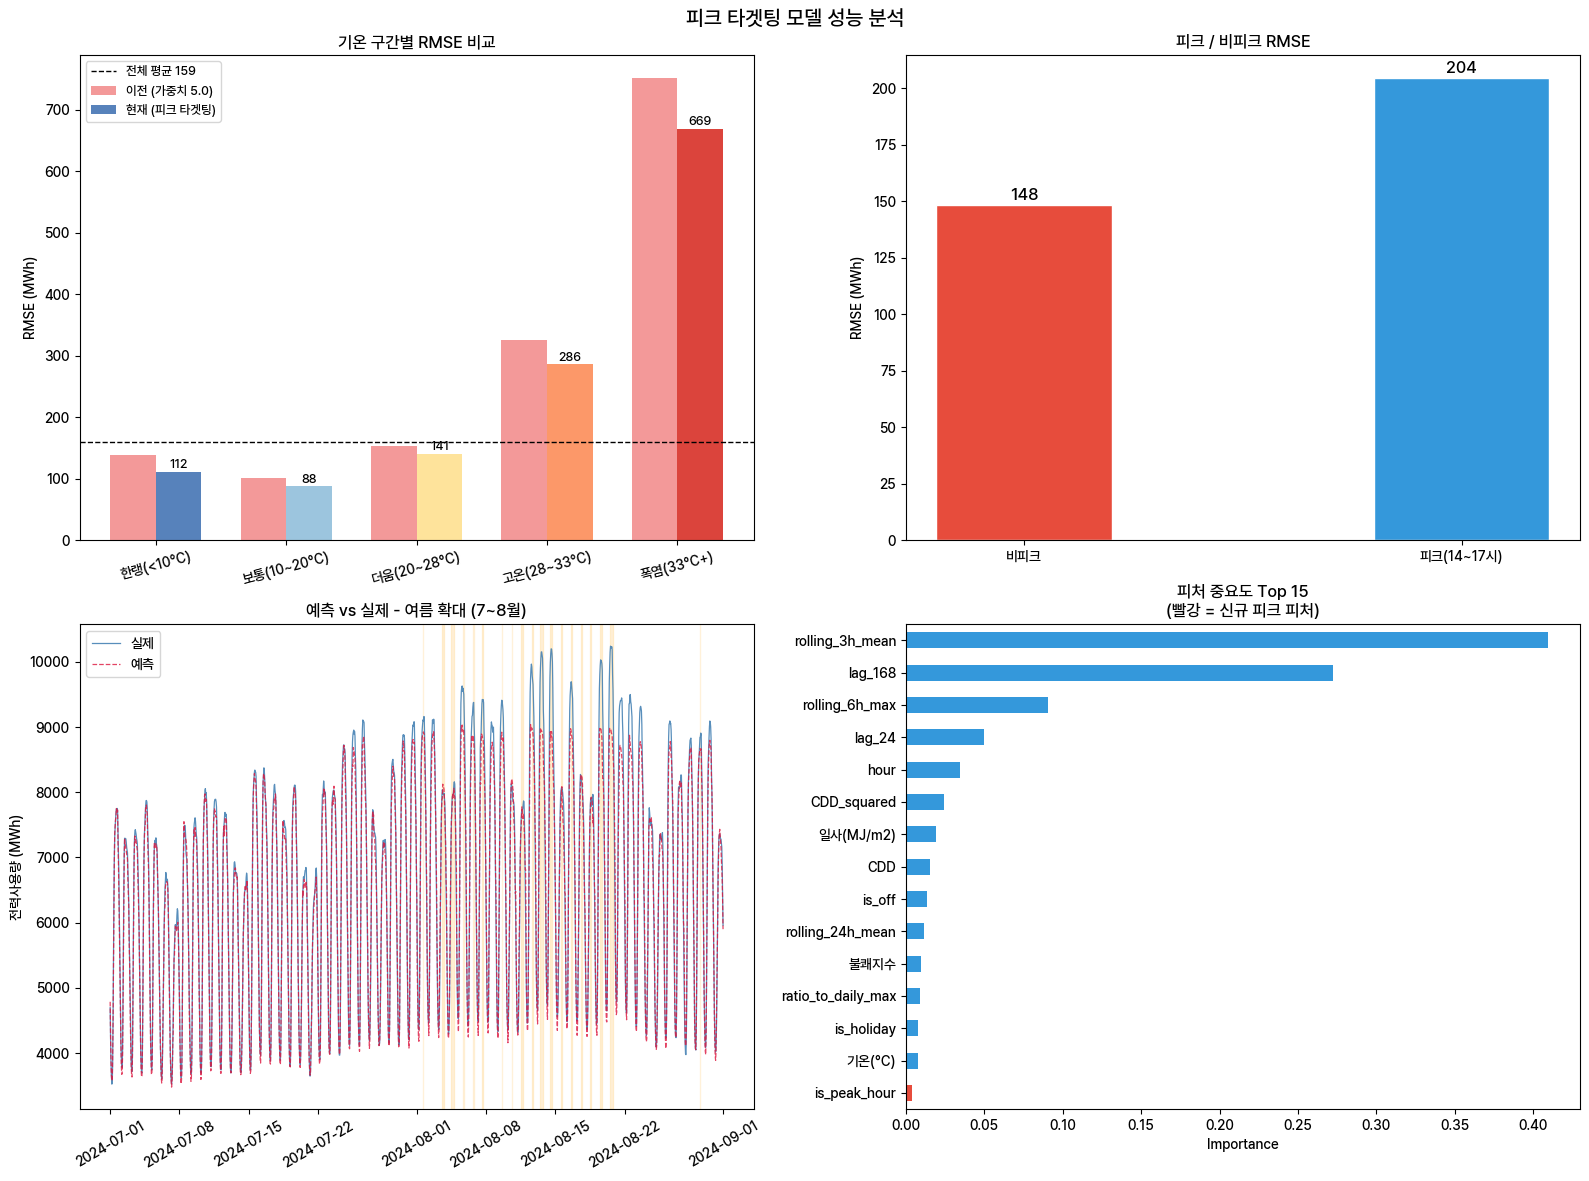

저장 완료: peak_targeting_result.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('피크 타겟팅 모델 성능 분석', fontsize=15, fontweight='bold')

colors = ['#4575b4', '#91bfdb', '#fee090', '#fc8d59', '#d73027']

# ── Plot 1: 기온 구간별 RMSE ─────────────────────────────────────────
ax = axes[0, 0]
# 이전 버전 RMSE (08번 결과 - 직접 입력)
prev_rmse = [139, 101, 154, 326, 751]  # 가중치 5.0 버전 기준
curr_rmse = zone_stats['RMSE'].values
x = np.arange(len(labels))
w = 0.35
bars1 = ax.bar(x - w/2, prev_rmse, w, label='이전 (가중치 5.0)', color='lightcoral', alpha=0.8)
bars2 = ax.bar(x + w/2, curr_rmse, w, label='현재 (피크 타겟팅)', color=colors, alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15)
ax.set_title('기온 구간별 RMSE 비교')
ax.set_ylabel('RMSE (MWh)')
ax.axhline(test_rmse, color='black', linestyle='--', linewidth=1, label=f'전체 평균 {test_rmse:.0f}')
ax.legend(fontsize=9)
for bar, val in zip(bars2, curr_rmse):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}', ha='center', va='bottom', fontsize=9)

# ── Plot 2: 피크 vs 비피크 RMSE ──────────────────────────────────────
ax = axes[0, 1]
peak_colors = ['#e74c3c', '#3498db']
bars = ax.bar(peak_stats.index, peak_stats['RMSE'], color=peak_colors, edgecolor='white', width=0.4)
ax.set_title('피크 / 비피크 RMSE')
ax.set_ylabel('RMSE (MWh)')
for bar, val in zip(bars, peak_stats['RMSE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# ── Plot 3: 예측 vs 실제 (여름 피크 구간 확대) ───────────────────────
ax = axes[1, 0]
summer = test_eval[(test_eval['datetime'].dt.month.between(7, 8))]
ax.plot(summer['datetime'], summer[TARGET], label='실제', color='steelblue', linewidth=0.9, alpha=0.9)
ax.plot(summer['datetime'], summer['pred'],  label='예측', color='crimson',   linewidth=0.9, alpha=0.8, linestyle='--')
heatwave_mask = summer['기온(°C)'] >= 33
if heatwave_mask.any():
    for _, group in summer[heatwave_mask].groupby((~heatwave_mask).cumsum()):
        ax.axvspan(group['datetime'].iloc[0], group['datetime'].iloc[-1],
                   alpha=0.15, color='orange')
ax.set_title('예측 vs 실제 - 여름 확대 (7~8월)')
ax.set_ylabel('전력사용량 (MWh)')
ax.legend()
ax.tick_params(axis='x', rotation=30)

# ── Plot 4: 피처 중요도 Top 15 ───────────────────────────────────────
ax = axes[1, 1]
importance = pd.Series(best_model.feature_importances_, index=FEATURES_PEAK)
top15 = importance.nlargest(15)
colors_imp = ['#e74c3c' if 'peak' in f or 'peak' in f else '#3498db' for f in top15.index]
top15.sort_values().plot(kind='barh', ax=ax, color=colors_imp[::-1])
ax.set_title('피처 중요도 Top 15\n(빨강 = 신규 피크 피처)')
ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig(r'C:\Users\User\Desktop\MyRepo\Portfolio\Portfolio_ver2\4_outputs\09_peak_targeting_commented\peak_targeting_result.png', dpi=300, bbox_inches='tight')
plt.show()
print('저장 완료: peak_targeting_result.png')

## 7. 전체 성능 비교 요약

## 📈 전체 개선 히스토리 요약
**4단계 개선 과정 요약**

| 단계 | 핵심 변경 | Test RMSE | 과적합 갭 |
|------|---------|-----------|---------|
| 기존 | 환경+lag | 244.8 | 203.8 |
| 1차 개선 | Rolling + CDD² + 폭염 피처 | 182.5 | 134.0 |
| 2차 개선 | 폭염 가중치 5.0 추가 | 171.2 | 117.2 |
| 3차 개선 | 피크 피처 + 복합 가중치 | **161.7** | **115.4** |

**총 34% RMSE 개선** - 에너지 도메인 지식(CDD, 피크 시간대, 폭염)을 단계적으로 모델에 녹인 결과

In [9]:
print('='*55)
print('전체 모델 개선 히스토리')
print('='*55)
history = [
    ('기존 (환경+lag)',          244.8, 203.8, None),
    ('개선 (rolling+CDD²)',      182.5, 134.0, None),
    ('+ 폭염 가중치 5.0',        171.2, 117.2, None),
    ('+ 피크 타겟팅 (현재)',     test_rmse, test_rmse-train_rmse, test_r2),
]
print(f'{'버전':<25} {'TestRMSE':>10} {'과적합갭':>10} {'R²':>8}')
print('-'*55)
for name, rmse, gap, r2 in history:
    r2_str = f'{r2:.4f}' if r2 else '-'
    print(f'{name:<25} {rmse:>10.1f} {gap:>10.1f} {r2_str:>8}')
print('='*55)
print(f'\n총 개선: {244.8 - test_rmse:.1f} RMSE 감소 ({(244.8-test_rmse)/244.8*100:.1f}% 개선)')

전체 모델 개선 히스토리
버전                          TestRMSE       과적합갭       R²
-------------------------------------------------------
기존 (환경+lag)                    244.8      203.8        -
개선 (rolling+CDD²)              182.5      134.0        -
+ 폭염 가중치 5.0                   171.2      117.2        -
+ 피크 타겟팅 (현재)                  159.0      121.8   0.9889

총 개선: 85.8 RMSE 감소 (35.1% 개선)


## 💾 모델 저장
**저장 파일 설명**
- `xgb_power_model_final.pkl` : 학습된 XGBoost 모델 (Streamlit 대시보드에서 로드)
- `features.json` : 사용된 피처 목록 (모델과 동일한 피처 순서 보장)

> Streamlit에서 사용 시:
> ```python
> import joblib, json
> model = joblib.load('xgb_power_model_final.pkl')
> features = json.load(open('features.json'))
> pred = model.predict(X[features])
> ```

In [10]:
# 모델 저장
import joblib
joblib.dump(best_model, r"C:\Users\User\Desktop\MyRepo\Portfolio\Portfolio_ver2\6_models\xgb_power_model_final.pkl")
print('최종 모델 저장 완료: xgb_power_model_final.pkl')

# 피처 목록도 저장 (Streamlit에서 사용)
import json
with open(r"C:\Users\User\Desktop\MyRepo\Portfolio\Portfolio_ver2\6_models\features.json", 'w', encoding='utf-8') as f:
    json.dump(FEATURES_PEAK, f, ensure_ascii=False)
print('피처 목록 저장 완료: features.json')

최종 모델 저장 완료: xgb_power_model_final.pkl
피처 목록 저장 완료: features.json
